# DBSCAN = Density-Based Spatial Clustering of Applications with Noise

    ✅ Finds dense regions in the data
    ✅ Builds clusters around those dense areas
    ✅ Marks isolated points as noise (outliers)


- Think of crowds in a busy railway station
    - Where many people are close together - a crowd forms
    - If only 1-2 people stand alone - we ignore them
    - Crowds form naturally, not in fixed shapes

- DBSCAN works exactly like this:
        "Wherever people are dense, call it a group. Otherwise, ignore."

- ⚙️ Two Main Parameters
- 1️⃣ eps (epsilon)
    👉 Maximum distance between two points to be considered neighbors.
    Think of it as a radius.
    - small eps → many small clusters + lots of noise
    - large eps → fewer big clusters

- 2️⃣ min_samples
    👉 Minimum number of nearby points required to form a dense region.

- 📌 Types of Points in DBSCAN
    DBSCAN classifies every sample into one of three roles:

    - 🟢 Core Point
        - Has enough neighbors inside eps.
        - This point creates clusters.

    - 🟡 Border Point
        - Close to a core point but doesn’t have - - enough neighbors itself.
        - Still belongs to the cluster.

    - 🔴 Noise Point (Outlier)
        - Not near any dense region.
        - Label = -1.
        - This is very useful for real-world data cleaning.

- 🔄 How DBSCAN Builds Clusters (Step-by-Step)

    - 1️⃣ Pick a point.
    - 2️⃣ Count neighbors inside radius (eps).
    - 3️⃣ If neighbors ≥ min_samples → start a cluster.
    - 4️⃣ Expand cluster by adding all reachable neighbors.
    - 5️⃣ Repeat until no dense region left.

- 📊 Why DBSCAN is Powerful
    - ✅ Advantages
        - Automatically finds number of clusters
        - Detects outliers naturally
        - Works well for irregular shapes
        - Good for noisy datasets

- Every cluster contains core points.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.cluster import DBSCAN # DBSCAN clustering algorithm
from sklearn.preprocessing import StandardScaler 

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [4]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

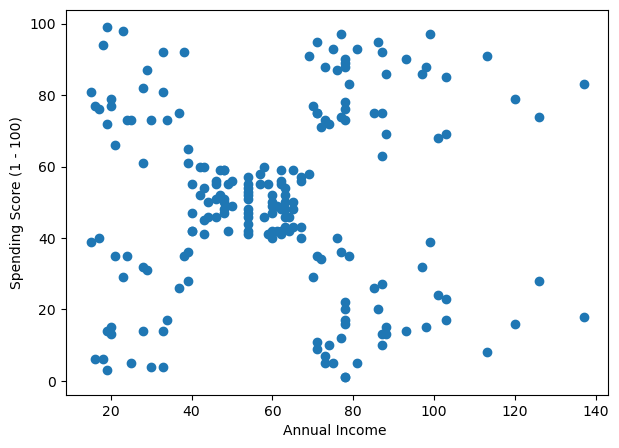

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel('Annual Income ')
plt.ylabel('Spending Score (1 - 100)')
plt.show()

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [15]:
dbscan = DBSCAN(eps = 0.3, min_samples = 5)
clusters = dbscan.fit_predict(X_scaled)

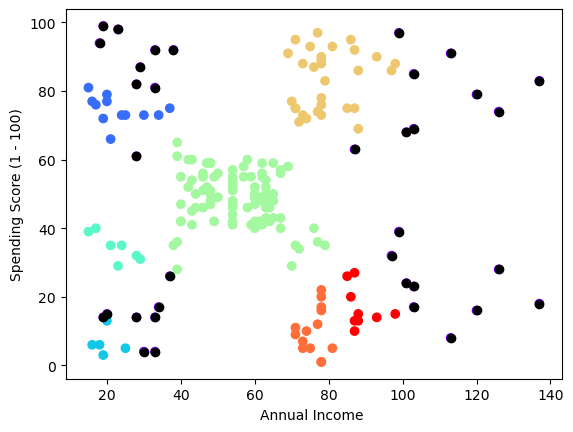

In [18]:
plt.Figure(figsize=(7, 5))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c = clusters, cmap = 'rainbow')
plt.scatter(X.iloc[clusters == -1]['Annual Income (k$)'], X.iloc[clusters == -1]['Spending Score (1-100)'],
color='black', label='Noise' )
plt.xlabel('Annual Income ')
plt.ylabel('Spending Score (1 - 100)')
plt.show()

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)
print('Silhouette Score for Hierarchical Clustering', score)

Silhouette Score for Hierarchical Clustering 0.31595469080938154


In [23]:
eps_value = [0.2, 0.3, 0.5]

for eps in eps_value:
    print(f"\n Evaluating DBSCAN using eps = {eps}")

    # Apply DBSCAN
    dbscan = DBSCAN(eps = eps, min_samples = 5)
    labels = dbscan.fit_predict(X_scaled)

    # NUmber of Clusters(Ignore Noise label -1)
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # NUmber of Noise Points
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise/len(labels)

    print(f"Number of Clusters: {n_clusters}")
    print(f"Number of Noise Points: ", {round(noise_ratio, 2)})

    # Silhouette score (only if valid)
    if n_clusters > 1:
        X_non_noise = X_scaled[labels != -1]
        labels_non_noise = labels[labels != -1]
        score = silhouette_score(X_non_noise, labels_non_noise)
        print("Silhouette score:", round(score, 3))
    else:
        print("Silhouette score: Not applicable")


 Evaluating DBSCAN using eps = 0.2
Number of Clusters: 7
Number of Noise Points:  {0.39}
Silhouette score: 0.586

 Evaluating DBSCAN using eps = 0.3
Number of Clusters: 7
Number of Noise Points:  {0.17}
Silhouette score: 0.524

 Evaluating DBSCAN using eps = 0.5
Number of Clusters: 2
Number of Noise Points:  {0.04}
Silhouette score: 0.388
